# Joining Oakland Business Licenses and Data Axle Into a Combined Business Dataset

This notebook builds the first **canonical Oakland business dataset**, constructed only from:

1. **City of Oakland Business License data (BL)**
2. **Data Axle (DA)**

**D&B is deliberately excluded from this merge.** The companion exploratory notebook
[`explore_all_business_data.ipynb`](./explore_all_business_data.ipynb) examined all three sources and
found that D&B's delivered extract contains no usable business name or street address field, cannot
support a longitudinal openings/closures panel in this delivery, and would require matching almost
entirely on spatial proximity + ZIP + sector compatibility -- i.e. weak, non-deterministic evidence.
Given this notebook's goal of a *conservative, high-confidence* merge, D&B does not clear that bar and
is left out. It can be revisited separately as a corroborating/enrichment layer, not as a merge input.

`explore_all_business_data.ipynb` is used throughout as the methodological reference for BL/DA field
meanings, address cleaning, the entity-vs-location distinction, prior BL-DA matching diagnostics, sector
mappings, and source-specific limitations -- but it is not edited, and this notebook is fully self-contained.

## Guiding philosophy

This notebook is **not** exploratory -- it produces and saves an actual combined dataset. The overriding
principle, repeated throughout:

> **Only merge two source records into one business entity when the evidence is strong enough that the
> match can reasonably be treated as definitive. Do not try to maximize the match rate. False positives
> (incorrectly merging two different businesses) are substantially worse than false negatives (failing to
> merge two records that really are the same business). Some genuine duplicates will remain unresolved,
> and that is an acceptable and intended cost of this approach.**

Fuzzy/approximate address similarity, nearest-geographic-point alone, and sector similarity alone are
**never** sufficient grounds for a merge in this notebook -- they are used only as corroborating diagnostics
once a deterministic address match already exists.

Two distinct concepts are maintained throughout: a **business entity** (a specific business/organization/
practitioner) and a **physical location** (an address/building). Multiple entities can legitimately share
one location -- this is especially common for Data Axle records in medical/professional buildings -- so
records are never collapsed into one entity merely because they share an address.

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.facecolor"] = "white"
tqdm.pandas()

In [2]:
# ---- source files (read-only) --------------------------------------------------------
BL_PATH = "../../data/business/Business License Corridors_050825.xlsx"
DA_PATH = "../../data/business/Oakland_DataAxleV2.xlsx"

# ---- output location -------------------------------------------------------------------
OUTPUT_DIR = "../../data/business/combined"
OUTPUT_MAIN_PATH = os.path.join(OUTPUT_DIR, "oakland_businesses_combined.csv")
OUTPUT_CROSSWALK_PATH = os.path.join(OUTPUT_DIR, "oakland_business_source_crosswalk.csv")

# ---- the subset of Data Axle's ~380 columns retained for this project ----
DA_RELEVANT_COLS = [
    "Company Name", "Address", "City", "State", "ZIP Code", "Neighborhood",
    "Latitude", "Longitude",
    "Primary NAICS", "Primary NAICS Description",
    "Primary SIC Code", "Primary SIC Description",
    "Location Type", "Type of Business", "Home Business",
    "Location Employee Size Range", "Location Employee Size Actual",
    "Location Sales Volume Range", "Location Sales Volume Actual",
    "Year Established", "Years In Database",
    "Franchise Description 1", "Affiliated Records", "Affiliated Locations",
    "Square Footage", "Credit Score Alpha", "Phone Number Combined",
    "Own or Lease", "Firm or Individual", "Government Office",
]

# ---- exact-duplicate identification columns (within-source processing duplicates only) ----
# BL: the full raw record has only 6 columns -- an exact duplicate means all 6 agree.
BL_EXACT_DUP_COLS = ["Bus address", "Bus City, State", "NAICS6D", "NAICS6D_Desc", "LON", "LAT"]
# DA: the full 383-column raw row has zero exact duplicates in this file, so "exact duplicate" is
# defined on a strict identifying subset -- name, address, zip, primary industry, coordinates, and
# phone all agreeing is treated as the same record appearing more than once in the source extract.
DA_EXACT_DUP_COLS = ["Company Name", "Address", "ZIP Code", "Primary NAICS", "Latitude", "Longitude",
                     "Phone Number Combined"]

# ---- local projected CRS for distance calculations (NAD83 / UTM zone 10N, meters) ----
GEO_CRS = "EPSG:4326"
LOCAL_CRS = "EPSG:26910"

# ---- broad-sector grouping, keyed on the first 2 digits of a NAICS code (from the exploratory nb) ----
NAICS2_TO_SECTOR = {
    "11": "Other / Unclassified", "21": "Other / Unclassified", "22": "Other / Unclassified",
    "23": "Construction",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation & Warehousing", "49": "Transportation & Warehousing",
    "51": "Other / Unclassified",
    "52": "Finance, Insurance & Real Estate", "53": "Finance, Insurance & Real Estate",
    "54": "Professional, Scientific & Technical Services",
    "55": "Other / Unclassified",
    "56": "Administrative & Support Services",
    "61": "Education",
    "62": "Health Care & Social Assistance",
    "71": "Arts, Entertainment & Recreation",
    "72": "Accommodation & Food Services",
    "81": "Other Services",
    "92": "Public / Institutional",
    "99": "Other / Unclassified",
}
SECTOR_ORDER = [
    "Retail Trade", "Accommodation & Food Services", "Health Care & Social Assistance",
    "Professional, Scientific & Technical Services", "Finance, Insurance & Real Estate",
    "Construction", "Manufacturing", "Transportation & Warehousing", "Wholesale Trade",
    "Administrative & Support Services", "Education", "Arts, Entertainment & Recreation",
    "Other Services", "Public / Institutional", "Other / Unclassified",
]

# ---- tentative, documented sector -> corridor-relevance grouping (never used to drop records) ----
SECTOR_TO_RELEVANCE = {
    "Retail Trade": "consumer_facing", "Accommodation & Food Services": "consumer_facing",
    "Arts, Entertainment & Recreation": "consumer_facing", "Health Care & Social Assistance": "consumer_facing",
    "Other Services": "consumer_facing",
    "Professional, Scientific & Technical Services": "office_or_professional",
    "Finance, Insurance & Real Estate": "office_or_professional",
    "Administrative & Support Services": "office_or_professional", "Education": "office_or_professional",
    "Public / Institutional": "office_or_professional",
    "Construction": "industrial_or_logistics", "Manufacturing": "industrial_or_logistics",
    "Transportation & Warehousing": "industrial_or_logistics", "Wholesale Trade": "industrial_or_logistics",
    "Other / Unclassified": "other",
}

# ---- NAICS description keywords used to flag likely property/rental licenses in BL (tentative) ----
# BL has no license-type field, so this is inferred only from the NAICS description text.
PROPERTY_LICENSE_NAICS_KEYWORDS = ["LESSORS OF", "REAL ESTATE PROPERTY MANAGERS", "PROPERTY MANAGERS"]

# ---- street-address normalization tables (from the exploratory notebook) ----
STREET_SUFFIX_MAP = {
    "STREET": "ST", "AVENUE": "AVE", "BOULEVARD": "BLVD", "DRIVE": "DR", "ROAD": "RD",
    "LANE": "LN", "PLACE": "PL", "COURT": "CT", "CIRCLE": "CIR", "TERRACE": "TER",
    "PARKWAY": "PKWY", "HIGHWAY": "HWY", "SQUARE": "SQ", "TRAIL": "TRL", "WAY": "WAY",
    "ALLEY": "ALY",
}
DIRECTION_MAP = {"NORTH": "N", "SOUTH": "S", "EAST": "E", "WEST": "W"}
UNIT_MARKER_TOKENS = {
    "#", "STE", "SUITE", "UNIT", "APT", "BLDG", "BUILDING", "NO", "RM", "ROOM", "FL",
    "FLOOR", "PMB",
}
STREET_SUFFIX_TOKENS = set(STREET_SUFFIX_MAP.values())

# ---- matching / validation thresholds ----
DISTANCE_THRESHOLDS_M = [10, 25, 50, 100]
# Coordinates that disagree by more than this, for an otherwise exact-address match, are treated as
# contradictory evidence and disqualify the pair from automatic (Tier 1/2/4) matching.
COORD_CONTRADICTION_THRESHOLD_M = 300
# Coordinate disagreement below the contradiction threshold but above this is still flagged for the
# validation section, without disqualifying the match.
COORD_REVIEW_FLAG_THRESHOLD_M = 50
# A base address with more than this many records on either side is treated as a large/shared building.
HIGH_COUNT_ADDR_THRESHOLD = 5
# For Tier 4 (unique correspondence inside an otherwise ambiguous address group): the isolated pair's
# coordinate distance must be at or below this ...
TIER4_ISOLATED_MATCH_M = 15
# ... and every other possible pairing in that group must be at or above this to count as "no plausible
# competing candidate."
TIER4_COMPETITOR_MIN_M = 100

SAMPLE_N = 5
RNG_SEED = 42
np.random.seed(RNG_SEED)

## 1. Load and Reproduce Source Processing

Both sources are loaded fresh in this notebook (self-contained, not imported from the exploratory
notebook). Every raw record -- before any cleaning, filtering, or deduplication -- is assigned a
`source_record_id` equal to its row position in the original file. This id is carried through every
later step so that every output row can be traced back to an original source record.

In [3]:
bl_raw = pd.read_excel(BL_PATH)
bl_raw["source_record_id"] = bl_raw.index.astype(str)

da_full = pd.read_excel(DA_PATH)
da_raw = da_full[DA_RELEVANT_COLS].copy()
da_raw["source_record_id"] = da_full.index.astype(str)

print("BL raw shape: ", bl_raw.shape)
print("DA raw shape (full): ", da_full.shape, " -> trimmed working frame:", da_raw.shape)
bl_raw.head(3)

BL raw shape:  (46514, 7)
DA raw shape (full):  (29545, 383)  -> trimmed working frame: (29545, 31)


,Bus address,"Bus City, State",NAICS6D,NAICS6D_Desc,LON,LAT,source_record_id
0,3775 ALAMEDA AVE STE B,"OAKLAND, CA 94601-3921",484110.0,"General Freight Trucking, Local",-122.223323,37.768064,0
1,7201 EARHART RD,"OAKLAND, CA 94621-4507",492110.0,Couriers,-122.216631,37.736097,1
2,1707 WOOD ST,"OAKLAND, CA 94607-1623",485999.0,All Other Transit and Ground Passenger Transportation,-122.295654,37.816101,2


**Note:** BL has no business-name field at all in this extract (only address, city/state, NAICS
code + description, and coordinates). This is not an oversight in this notebook -- no name field will be
fabricated for BL anywhere below.

In [4]:
print("DA has a business name (\"Company Name\"); BL columns available:")
print(list(bl_raw.columns))

DA has a business name ("Company Name"); BL columns available:
['Bus address', 'Bus City, State', 'NAICS6D', 'NAICS6D_Desc', 'LON', 'LAT', 'source_record_id']


## 2. Clean and Standardize Addresses

Address normalization reuses the approach validated in the exploratory notebook: uppercase, strip
punctuation/whitespace, expand common directionals, and abbreviate common street-suffix words
(STREET -> ST, AVENUE -> AVE, etc.) so that trivial formatting differences don't block a match.

This is deliberately **conservative**: house number, street name, and unit number are never altered or
fuzzed. `address_normalized` keeps unit/suite information; `address_base` strips it so that records at
the same building can be identified (used later for location grouping), while `unit` retains what was
stripped out.

In [5]:
def normalize_address(addr):
    """Uppercase, trim, and normalize punctuation / whitespace / common street words."""
    if pd.isna(addr):
        return np.nan
    s = str(addr).upper().replace(".", "").replace(",", " ")
    s = re.sub(r"#\s*", "# ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [DIRECTION_MAP.get(t, t) for t in s.split(" ")]
    tokens = [STREET_SUFFIX_MAP.get(t, t) for t in tokens]
    return " ".join(tokens).strip()


def split_unit(addr_norm):
    """Split a normalized address into (base_address, unit), by marker token or trailing suffix."""
    if pd.isna(addr_norm):
        return np.nan, np.nan
    tokens = addr_norm.split(" ")
    marker_idx = next((i for i, t in enumerate(tokens) if t in UNIT_MARKER_TOKENS), None)
    if marker_idx is not None and marker_idx < len(tokens) - 1:
        base, unit_tokens = " ".join(tokens[:marker_idx]), tokens[marker_idx + 1:]
    else:
        suffix_idx = max((i for i, t in enumerate(tokens) if t in STREET_SUFFIX_TOKENS), default=None)
        if suffix_idx is not None and suffix_idx < len(tokens) - 1:
            base, unit_tokens = " ".join(tokens[:suffix_idx + 1]), tokens[suffix_idx + 1:]
        else:
            return addr_norm, np.nan
    unit = " ".join(unit_tokens).strip() or np.nan
    return (base.strip() or addr_norm), unit


def naics_to_sector(naics_code):
    if pd.isna(naics_code):
        return "Other / Unclassified"
    return NAICS2_TO_SECTOR.get(str(naics_code)[:2], "Other / Unclassified")


# ---- house-number strictness check: two nearby addresses on the same block must NOT collapse ----
assert normalize_address("725 International Blvd") != normalize_address("825 International Blvd")
assert split_unit(normalize_address("725 International Blvd"))[0] != split_unit(normalize_address("825 International Blvd"))[0]
print("House-number strictness check passed: differing house numbers never normalize to the same address.")

House-number strictness check passed: differing house numbers never normalize to the same address.


In [6]:
bl_std = bl_raw.copy()
bl_std["address_original"] = bl_std["Bus address"]
bl_std["address_norm"] = bl_std["address_original"].apply(normalize_address)
bl_std[["address_base", "address_unit"]] = bl_std["address_norm"].apply(lambda a: pd.Series(split_unit(a)))
bl_std["city"] = bl_std["Bus City, State"].str.split(",").str[0].str.strip()
bl_std["state"] = bl_std["Bus City, State"].str.extract(r",\s*([A-Z]{2})\s")[0]
bl_std["zip5"] = bl_std["Bus City, State"].str.extract(r"(\d{5})")
bl_std["lat_std"], bl_std["lon_std"] = bl_std["LAT"], bl_std["LON"]
bl_std["naics_code_std"] = bl_std["NAICS6D"].dropna().astype("int64").astype(str)
bl_std["sector"] = bl_std["NAICS6D"].apply(naics_to_sector)
# ---- alias onto the common cross-source schema named in this project's spec ----
bl_std["source"] = "BL"
bl_std["business_name"] = np.nan  # not present in this BL extract -- explicit, not fabricated
bl_std["address_normalized"] = bl_std["address_norm"]
bl_std["industry_code_original"] = bl_std["NAICS6D"]
bl_std["industry_description_original"] = bl_std["NAICS6D_Desc"]

da_std = da_raw.copy()
da_std["address_original"] = da_std["Address"]
da_std["address_norm"] = da_std["address_original"].apply(normalize_address)
da_std[["address_base", "address_unit"]] = da_std["address_norm"].apply(lambda a: pd.Series(split_unit(a)))
da_std["zip5"] = da_std["ZIP Code"].astype(str).str.extract(r"(\d{5})")
da_std["lat_std"], da_std["lon_std"] = da_std["Latitude"], da_std["Longitude"]
da_std["naics_code_std"] = da_std["Primary NAICS"].dropna().astype("int64").astype(str)
da_std["sector"] = da_std["Primary NAICS"].apply(naics_to_sector)
# ---- alias onto the common cross-source schema named in this project's spec ----
da_std["source"] = "DA"
da_std["business_name"] = da_std["Company Name"]
da_std["address_normalized"] = da_std["address_norm"]
da_std["industry_code_original"] = da_std["Primary NAICS"]
da_std["industry_description_original"] = da_std["Primary NAICS Description"]

print("bl_std:", bl_std.shape, " da_std:", da_std.shape)
bl_std[["address_original", "address_norm", "address_base", "address_unit", "city", "state", "zip5"]].head(SAMPLE_N)

bl_std: (46514, 23)  da_std: (29545, 45)


,address_original,address_norm,address_base,address_unit,city,state,zip5
0,3775 ALAMEDA AVE STE B,3775 ALAMEDA AVE STE B,3775 ALAMEDA AVE,B,OAKLAND,CA,94601
1,7201 EARHART RD,7201 EARHART RD,7201 EARHART RD,NaN,OAKLAND,CA,94621
2,1707 WOOD ST,1707 WOOD ST,1707 WOOD ST,NaN,OAKLAND,CA,94607
3,530 WATER ST,530 WATER ST,530 WATER ST,NaN,OAKLAND,CA,94607
4,737 BAY ST,737 BAY ST,737 BAY ST,NaN,OAKLAND,CA,94607


**Takeaway:** normalization only touches formatting (case, punctuation, spelling-out of suffixes/directionals) -- house number and street identity are preserved exactly, and a unit/suite is split out separately rather than discarded, so it remains available as corroborating (not primary) evidence.

## 3. Re-Establish the BL-DA Matching Baseline

Before building the conservative merge, the exploratory notebook's key BL-DA address-matching
diagnostics are recomputed here on this notebook's own standardized frames (recomputed on the **raw**,
not-yet-deduplicated data, to make the comparison to the prior notebook direct). The prior notebook found
roughly: 48.5% of DA records match a BL full address, 77.5% match a BL base address, 33.4% of BL records
match a DA base address, and only ~42% of shared base addresses are one-to-one.

**The central conceptual point, repeated throughout this notebook: an address match means the records
share a location. It does not by itself mean they are the same business entity.**

In [7]:
bl_norm_set, bl_base_set = set(bl_std["address_norm"].dropna()), set(bl_std["address_base"].dropna())
da_norm_set, da_base_set = set(da_std["address_norm"].dropna()), set(da_std["address_base"].dropna())

da_std["matched_full_addr"] = da_std["address_norm"].notna() & da_std["address_norm"].isin(bl_norm_set)
da_std["matched_base_addr"] = da_std["address_base"].notna() & da_std["address_base"].isin(bl_base_set)
bl_std["matched_base_addr"] = bl_std["address_base"].notna() & bl_std["address_base"].isin(da_base_set)

print(f"DA records matching a BL address exactly (full, incl. unit): {da_std['matched_full_addr'].mean()*100:.1f}%")
print(f"DA records matching a BL address on base street only:       {da_std['matched_base_addr'].mean()*100:.1f}%")
print(f"BL records matching a DA base street address:                {bl_std['matched_base_addr'].mean()*100:.1f}%")

DA records matching a BL address exactly (full, incl. unit): 48.5%
DA records matching a BL address on base street only:       77.5%
BL records matching a DA base street address:                33.4%


In [8]:
bl_key_counts, da_key_counts = bl_std["address_base"].value_counts(), da_std["address_base"].value_counts()
common_keys = set(bl_key_counts.index) & set(da_key_counts.index)

def classify_cardinality(k):
    b, d = bl_key_counts[k], da_key_counts[k]
    if b == 1 and d == 1: return "one-to-one"
    if b == 1 or d == 1: return "one-to-many"
    return "many-to-many"

cardinality = pd.Series([classify_cardinality(k) for k in common_keys]).value_counts(normalize=True) * 100
print(f"{len(common_keys):,} base addresses shared by BL and DA. Cardinality of shared base addresses:")
print(cardinality.round(1))

6,244 base addresses shared by BL and DA. Cardinality of shared base addresses:
one-to-one      41.6
one-to-many     35.5
many-to-many    23.0
Name: proportion, dtype: float64


In [9]:
bl_geo_pts = bl_std.dropna(subset=["lat_std", "lon_std"])
da_geo_pts = da_std.dropna(subset=["lat_std", "lon_std"])
bl_gdf_all = gpd.GeoDataFrame(bl_geo_pts, geometry=gpd.points_from_xy(bl_geo_pts["lon_std"], bl_geo_pts["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)
da_gdf_all = gpd.GeoDataFrame(da_geo_pts, geometry=gpd.points_from_xy(da_geo_pts["lon_std"], da_geo_pts["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)

nearest = gpd.sjoin_nearest(da_gdf_all, bl_gdf_all[["geometry"]], distance_col="dist_m", how="left")
nearest = nearest[~nearest.index.duplicated(keep="first")]
for thresh in DISTANCE_THRESHOLDS_M:
    print(f"DA records with a BL point within {thresh:>3d}m: {(nearest['dist_m'] <= thresh).mean()*100:5.1f}%")

DA records with a BL point within  10m:  12.1%
DA records with a BL point within  25m:  43.8%
DA records with a BL point within  50m:  72.9%
DA records with a BL point within 100m:  92.1%


**Takeaway:** these figures are consistent with the exploratory notebook's baseline (same
normalization logic, same sources). Roughly half of DA records share a full address with some BL record,
about three-quarters share a base street address, and fewer than half of shared base addresses are
genuinely one-to-one -- confirming that address matching alone, without further evidence, would produce
a large number of ambiguous one-to-many and many-to-many groupings. This motivates the tiered,
conservative approach below rather than a blanket address join.

## 4. Distinguish Business Entities From Physical Locations

Two concepts are kept separate throughout this notebook:

- A **physical location** is an address/building.
- A **business entity** is a specific business, organization, establishment, practitioner, or licensed
  activity.

Multiple entities can legitimately occupy one location -- most visibly in Data Axle, where medical and
professional office buildings often list each practitioner or tenant as a separate record at the same
address. **Records are never collapsed into one entity merely because they share a base address.** The
example below illustrates why: a single high-count DA address hosts several genuinely distinct
businesses, not duplicate listings of the same business.

In [10]:
da_addr_counts = da_std["address_base"].value_counts()
example_addr = da_addr_counts.index[0]
example_cols = ["Company Name", "address_original", "Primary NAICS Description", "Location Type"]
print(f"Example: {da_addr_counts.iloc[0]} DA records share base address {example_addr!r}")
da_std.loc[da_std["address_base"] == example_addr, example_cols].head(10)

Example: 713 DA records share base address '1411 E 31ST ST'


,Company Name,address_original,Primary NAICS Description,Location Type
410,Aarabi Shahram MD,1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
441,Abdelrahim Marwan MD,1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
484,"Abram, Sharon A",1411 E 31st St,Offices Of Mental Health Practitioners (Except Phy,Single Loc
500,Abulhasan Ahmad DO,1411 E 31st St # 2,Offices Of Physicians (Except Mental Health Specia,Single Loc
595,Acosta Jose Antonio MD,1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
669,Addepalli Aravind MD,1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
685,"Adewole, Virginia A MD",1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
691,"Adkins, Claire MD",1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
695,"Adler, Naomi A MD",1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc
717,Adult Immunology Clinic,1411 E 31st St,Offices Of Physicians (Except Mental Health Specia,Single Loc


This notebook will therefore produce, for every canonical business entity, both a `canonical_business_id` (the entity) and a `location_id` (the physical location) -- multiple `canonical_business_id` values may legitimately share one `location_id`.

## 5. Identify Exact Duplicates Within Each Source

Before any cross-source matching, each source is checked for **exact processing duplicates** -- records
that are identical across all relevant identifying fields, which most likely represent the same
underlying record appearing more than once in the source extract rather than two different businesses.

This is deliberately narrow: records are **not** deduplicated merely for sharing an address, name,
coordinates, or sector, since multiple legitimate entities can share all of those.

- **BL** has only 6 raw columns; an exact duplicate means all 6 agree (`BL_EXACT_DUP_COLS`).
- **DA**'s full 383-column raw row has zero exact full-row duplicates in this file, so "exact duplicate"
  is instead defined on a strict identifying subset -- company name, address, ZIP, primary NAICS,
  coordinates, and phone number all agreeing (`DA_EXACT_DUP_COLS`). Two DA rows agreeing on all seven of
  these fields are treated as the same record duplicated, not two coincidentally-identical businesses.

Only the first occurrence of each exact-duplicate group is kept; every removed `source_record_id` is
retained in a list for the final reconciliation table (Section 17).

In [11]:
bl_dup_mask = bl_std.duplicated(subset=BL_EXACT_DUP_COLS, keep="first")
da_dup_mask = da_std.duplicated(subset=DA_EXACT_DUP_COLS, keep="first")

bl_removed_dup_ids = bl_std.loc[bl_dup_mask, "source_record_id"].tolist()
da_removed_dup_ids = da_std.loc[da_dup_mask, "source_record_id"].tolist()

bl_work = bl_std.loc[~bl_dup_mask].copy().reset_index(drop=True)
da_work = da_std.loc[~da_dup_mask].copy().reset_index(drop=True)

print(f"BL: {len(bl_std):,} raw records -> {len(bl_removed_dup_ids):,} exact duplicates removed -> {len(bl_work):,} working records")
print(f"DA: {len(da_std):,} raw records -> {len(da_removed_dup_ids):,} exact duplicates removed -> {len(da_work):,} working records")

BL: 46,514 raw records -> 1,086 exact duplicates removed -> 45,428 working records
DA: 29,545 raw records -> 398 exact duplicates removed -> 29,147 working records


In [12]:
print("Example DA exact-duplicate group (all identifying fields agree):")
example_group = da_std[da_std.duplicated(subset=DA_EXACT_DUP_COLS, keep=False)].sort_values(DA_EXACT_DUP_COLS)
example_group[["source_record_id"] + DA_EXACT_DUP_COLS].head(6)

Example DA exact-duplicate group (all identifying fields agree):


,source_record_id,Company Name,Address,ZIP Code,Primary NAICS,Latitude,Longitude,Phone Number Combined
308,308,A H S 835 Clinic,835 Webster St,94607,62111107,37.799723,-122.271154,(510) 318-5800
309,309,A H S 835 Clinic,835 Webster St,94607,62111107,37.799723,-122.271154,(510) 318-5800
310,310,A H S 835 Clinic,835 Webster St,94607,62111107,37.799723,-122.271154,(510) 318-5800
725,725,Advanced Dental Concepts,1708 Franklin St,94612,62121003,37.806235,-122.268386,(510) 465-7777
726,726,Advanced Dental Concepts,1708 Franklin St,94612,62121003,37.806235,-122.268386,(510) 465-7777
727,727,Advanced Dental Concepts,1708 Franklin St,94612,62121003,37.806235,-122.268386,(510) 465-7777


**Takeaway:** all subsequent matching and canonical-entity construction uses `bl_work`/`da_work` (post-deduplication). `bl_std`/`da_std` are left untouched above for the baseline comparison in Section 3.

## 6. Build a Very Conservative Deterministic Matching Hierarchy

Matching rules are applied from strongest to weakest evidence. The guiding rule: **produce a smaller
number of extremely reliable matches rather than a larger number of questionable ones.** Every automatic
match below is deterministic (based on exact address agreement plus uniqueness), never based on fuzzy
similarity, sector agreement alone, or spatial proximity alone.

Coordinates (where both sources have them) are computed for every candidate pair and used as
**corroboration**: a coordinate disagreement beyond `COORD_CONTRADICTION_THRESHOLD_M` (300m) is treated
as contradictory evidence and the pair is **not** matched, even though the addresses agree exactly --
this is the one place spatial evidence can veto an otherwise-deterministic address match. Smaller
disagreements (above `COORD_REVIEW_FLAG_THRESHOLD_M`, still under the contradiction threshold) are kept
as matches but flagged for manual review. Sector agreement is recorded for every pair but, per the
project's own instructions, is **never** used to invalidate a match -- coding differences between
sources are expected and documented separately (Section 9).

In [13]:
# ---- projected coordinates for every working record with valid lat/lon, used for all distance checks ----
bl_geo = bl_work.dropna(subset=["lat_std", "lon_std"]).copy()
da_geo = da_work.dropna(subset=["lat_std", "lon_std"]).copy()
bl_gdf = gpd.GeoDataFrame(bl_geo, geometry=gpd.points_from_xy(bl_geo["lon_std"], bl_geo["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)
da_gdf = gpd.GeoDataFrame(da_geo, geometry=gpd.points_from_xy(da_geo["lon_std"], da_geo["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)
bl_xy = pd.DataFrame({"x": bl_gdf.geometry.x.values, "y": bl_gdf.geometry.y.values}, index=bl_gdf["source_record_id"].values)
da_xy = pd.DataFrame({"x": da_gdf.geometry.x.values, "y": da_gdf.geometry.y.values}, index=da_gdf["source_record_id"].values)

def pair_distance_m(bl_ids, da_ids):
    """Vectorized straight-line distance (meters, projected CRS) between aligned bl_id/da_id arrays."""
    bx = bl_xy.reindex(bl_ids)[["x", "y"]].values
    dx = da_xy.reindex(da_ids)[["x", "y"]].values
    return np.hypot(bx[:, 0] - dx[:, 0], bx[:, 1] - dx[:, 1])

def sector_conflict(bl_sectors, da_sectors):
    known = (bl_sectors != "Other / Unclassified") & (da_sectors != "Other / Unclassified")
    return known & (bl_sectors != da_sectors)

matched_pairs = []  # list of dicts: bl_id, da_id, match_method, match_confidence
excluded_contradictions = []  # candidate pairs rejected for contradictory coordinates

bl_by_id = bl_work.set_index("source_record_id", drop=False)
da_by_id = da_work.set_index("source_record_id", drop=False)

print("bl_gdf / da_gdf / distance helpers ready:", bl_xy.shape, da_xy.shape)

bl_gdf / da_gdf / distance helpers ready: (44874, 2) (29147, 2)


### Tier 1 -- exact full address, clean one-to-one

The strongest class: BL and DA full normalized addresses (including unit) are identical, and that exact
address corresponds to exactly one BL record and exactly one DA record in the deduplicated working data.
(This automatically absorbs the "duplicate source records already resolved" case from the original
matching-hierarchy sketch: if an address only becomes 1:1 *because* Section 5 removed a duplicate, it is
still evaluated -- and matched -- here, on the post-dedup frames.)

In [14]:
bl_full_counts = bl_work["address_norm"].value_counts()
da_full_counts = da_work["address_norm"].value_counts()
tier1_addrs = [a for a in (set(bl_full_counts[bl_full_counts == 1].index) & set(da_full_counts[da_full_counts == 1].index)) if pd.notna(a)]

bl_t1 = bl_work[bl_work["address_norm"].isin(tier1_addrs)].set_index("address_norm")
da_t1 = da_work[da_work["address_norm"].isin(tier1_addrs)].set_index("address_norm")
t1 = bl_t1[["source_record_id", "sector"]].join(da_t1[["source_record_id", "sector"]], lsuffix="_bl", rsuffix="_da")

t1["dist_m"] = pair_distance_m(t1["source_record_id_bl"].values, t1["source_record_id_da"].values)
t1["sector_conflict"] = sector_conflict(t1["sector_bl"].values, t1["sector_da"].values)
t1_contradicted = t1["dist_m"] > COORD_CONTRADICTION_THRESHOLD_M  # NaN (missing coords) -> False, not contradicted

for row in t1[~t1_contradicted].itertuples():
    matched_pairs.append(dict(bl_id=row.source_record_id_bl, da_id=row.source_record_id_da,
                              match_method="exact_full_address_one_to_one", match_confidence="high",
                              dist_m=row.dist_m, sector_conflict=row.sector_conflict))
for row in t1[t1_contradicted].itertuples():
    excluded_contradictions.append(dict(bl_id=row.source_record_id_bl, da_id=row.source_record_id_da,
                                         reason="coordinate_contradiction", dist_m=row.dist_m, tier="tier1_candidate"))

print(f"Tier 1 candidates: {len(t1):,} exact one-to-one full-address pairs; "
      f"{t1_contradicted.sum():,} excluded for coordinate contradiction (>{COORD_CONTRADICTION_THRESHOLD_M}m); "
      f"{len(t1) - t1_contradicted.sum():,} matched.")

Tier 1 candidates: 2,716 exact one-to-one full-address pairs; 50 excluded for coordinate contradiction (>300m); 2,666 matched.


### Tier 2 -- exact base address, clean one-to-one

Where the base street address (unit stripped) corresponds to exactly one BL record and exactly one DA
record. Because unit information may differ or be missing on one side, this is still a strong
deterministic match when the underlying site is genuinely one-to-one -- it is only reached for pairs not
already resolved by Tier 1 (i.e. their full address strings differed, e.g. one side is missing a unit
that the other has).

In [15]:
bl_base_counts = bl_work["address_base"].value_counts()
da_base_counts = da_work["address_base"].value_counts()
tier2_addrs = [a for a in (set(bl_base_counts[bl_base_counts == 1].index) & set(da_base_counts[da_base_counts == 1].index)) if pd.notna(a)]

bl_t2 = bl_work[bl_work["address_base"].isin(tier2_addrs)].set_index("address_base")
da_t2 = da_work[da_work["address_base"].isin(tier2_addrs)].set_index("address_base")
t2 = bl_t2[["source_record_id", "sector"]].join(da_t2[["source_record_id", "sector"]], lsuffix="_bl", rsuffix="_da")

already_matched_bl = {m["bl_id"] for m in matched_pairs}
already_matched_da = {m["da_id"] for m in matched_pairs}
t2_new = t2[~t2["source_record_id_bl"].isin(already_matched_bl) & ~t2["source_record_id_da"].isin(already_matched_da)]

t2_new = t2_new.copy()
t2_new["dist_m"] = pair_distance_m(t2_new["source_record_id_bl"].values, t2_new["source_record_id_da"].values)
t2_new["sector_conflict"] = sector_conflict(t2_new["sector_bl"].values, t2_new["sector_da"].values)
t2_contradicted = t2_new["dist_m"] > COORD_CONTRADICTION_THRESHOLD_M

for row in t2_new[~t2_contradicted].itertuples():
    matched_pairs.append(dict(bl_id=row.source_record_id_bl, da_id=row.source_record_id_da,
                              match_method="exact_base_address_one_to_one", match_confidence="high",
                              dist_m=row.dist_m, sector_conflict=row.sector_conflict))
for row in t2_new[t2_contradicted].itertuples():
    excluded_contradictions.append(dict(bl_id=row.source_record_id_bl, da_id=row.source_record_id_da,
                                         reason="coordinate_contradiction", dist_m=row.dist_m, tier="tier2_candidate"))

print(f"Tier 2 candidates (base-address 1:1, not already Tier 1): {len(t2_new):,}; "
      f"{t2_contradicted.sum():,} excluded for coordinate contradiction; "
      f"{len(t2_new) - t2_contradicted.sum():,} matched.")

Tier 2 candidates (base-address 1:1, not already Tier 1): 337; 52 excluded for coordinate contradiction; 285 matched.


### Tier 4 -- unique correspondence inside an otherwise ambiguous full address

This tier is deliberately narrow and is expected to match few or zero pairs -- that is a feature of the
conservative philosophy, not a shortcoming. It only applies where the exact full address (with unit)
matches but is **not** one-to-one (e.g. two DA rows were entered under the same suite address). Within
such a group, a pair is matched only if:

- every BL and DA record in the group has valid coordinates (if any record lacks coordinates, the group
  cannot be ruled unambiguous, and nothing in it is matched), **and**
- exactly one BL-DA pair in the group is within `TIER4_ISOLATED_MATCH_M` (15m), **and**
- every other possible pairing in that same group is at or beyond `TIER4_COMPETITOR_MIN_M` (100m) --
  i.e. there is no plausible competing candidate.

If there is any ambiguity in a group, nothing in it is matched here.

In [16]:
already_matched_bl = {m["bl_id"] for m in matched_pairs}
already_matched_da = {m["da_id"] for m in matched_pairs}

tier4_full_addrs = [a for a in (set(bl_full_counts.index) & set(da_full_counts.index))
                     if pd.notna(a) and (bl_full_counts[a] > 1 or da_full_counts[a] > 1)]

tier4_matches = []
for addr in tqdm(tier4_full_addrs, desc="Tier 4: scanning ambiguous full-address groups"):
    bl_ids = bl_work.loc[bl_work["address_norm"] == addr, "source_record_id"].tolist()
    da_ids = da_work.loc[da_work["address_norm"] == addr, "source_record_id"].tolist()
    bl_ids = [i for i in bl_ids if i not in already_matched_bl]
    da_ids = [i for i in da_ids if i not in already_matched_da]
    if not bl_ids or not da_ids:
        continue
    if not (set(bl_ids) <= set(bl_xy.index) and set(da_ids) <= set(da_xy.index)):
        continue  # missing coordinates somewhere in the group -- cannot rule out a competing candidate
    dmat = np.array([[pair_distance_m([b], [d])[0] for d in da_ids] for b in bl_ids])
    close = np.argwhere(dmat <= TIER4_ISOLATED_MATCH_M)
    if len(close) != 1:
        continue
    bi, di = close[0]
    others = dmat.copy()
    others[bi, di] = np.inf
    if others.min() < TIER4_COMPETITOR_MIN_M:
        continue
    tier4_matches.append(dict(bl_id=bl_ids[bi], da_id=da_ids[di], dist_m=dmat[bi, di]))

for m in tier4_matches:
    matched_pairs.append(dict(bl_id=m["bl_id"], da_id=m["da_id"],
                              match_method="exact_unit_unique_correspondence", match_confidence="medium",
                              dist_m=m["dist_m"], sector_conflict=False))

print(f"Tier 4: {len(tier4_full_addrs):,} ambiguous full-address groups scanned -> {len(tier4_matches):,} matched.")

Tier 4: scanning ambiguous full-address groups:   0%|          | 0/2818 [00:00<?, ?it/s]

Tier 4: 2,818 ambiguous full-address groups scanned -> 1 matched.


In [17]:
matched_pairs_df = pd.DataFrame(matched_pairs)
excluded_contradictions_df = pd.DataFrame(excluded_contradictions)
print(f"Total deterministic matches (Tiers 1+2+4): {len(matched_pairs_df):,}")
print(matched_pairs_df["match_method"].value_counts())
print(f"\nCandidate pairs excluded for coordinate contradiction (address matched, coords did not): {len(excluded_contradictions_df):,}")

Total deterministic matches (Tiers 1+2+4): 2,952
match_method
exact_full_address_one_to_one       2666
exact_base_address_one_to_one        285
exact_unit_unique_correspondence       1
Name: count, dtype: int64

Candidate pairs excluded for coordinate contradiction (address matched, coords did not): 102


**Takeaway:** the hierarchy is intentionally front-loaded -- Tiers 1 and 2 (pure address-uniqueness) carry essentially all of the confident matches, and Tier 4's narrow coordinate-isolation rule adds only a small number of additional matches inside genuinely ambiguous buildings. This is the intended shape of a conservative hierarchy: strong evidence does most of the work, and weaker circumstantial evidence is used sparingly and only where it can rule out every alternative.

## 7. What Not to Match

The following are explicitly **not** used to create an automatic match anywhere in this notebook:

- base-address matches with more than one plausible candidate on either side
- many-to-many address groups
- spatially close businesses without exact address agreement
- fuzzy street-name or approximate-similarity matches
- records with different house numbers
- records where only sector agrees
- records where only coordinates are close
- records that "probably" look like the same business but cannot be demonstrated deterministically

Every BL or DA record that shares a base address with the other source but was **not** resolved into a
Tier 1/2/4 match is tagged `ambiguous_shared_location = True` once the canonical table is built (Section
10) -- it remains a separate canonical entity, but the tag preserves the fact that a same-location,
unreconciled counterpart exists on the other side.

## 8. Spatial Proximity as Corroboration Only

Coordinates were already used above as a **veto** (contradiction check) and, narrowly, inside Tier 4.
Here the resulting distances for all *matched* pairs are summarized as a diagnostic -- to confirm the
matches look spatially sensible and to surface any pairs worth a manual look, not to create new matches.
Distance is never used on its own to establish identity: several distinct businesses in the same
building, or a shared building-centroid geocode, can put unrelated records within a few meters of each
other.

In [18]:
dist_valid = matched_pairs_df["dist_m"].dropna()
print(f"Matched pairs with coordinates on both sides: {len(dist_valid):,} of {len(matched_pairs_df):,}")
print(dist_valid.describe().round(1))
for thresh in [5, 15, 50, COORD_REVIEW_FLAG_THRESHOLD_M, COORD_CONTRADICTION_THRESHOLD_M]:
    print(f"  within {thresh:>4d}m: {(dist_valid <= thresh).mean()*100:5.1f}%")

matched_pairs_df["coord_flag"] = matched_pairs_df["dist_m"].between(COORD_REVIEW_FLAG_THRESHOLD_M, COORD_CONTRADICTION_THRESHOLD_M)
print(f"\nFlagged for manual coordinate review ({COORD_REVIEW_FLAG_THRESHOLD_M}-{COORD_CONTRADICTION_THRESHOLD_M}m): {matched_pairs_df['coord_flag'].sum():,}")

Matched pairs with coordinates on both sides: 2,843 of 2,952
count    2843.0
mean       36.2
std        34.0
min         0.5
25%        17.3
50%        27.6
75%        43.6
max       292.8
Name: dist_m, dtype: float64
  within    5m:   5.8%
  within   15m:  19.6%
  within   50m:  81.1%
  within   50m:  81.1%
  within  300m: 100.0%

Flagged for manual coordinate review (50-300m): 538


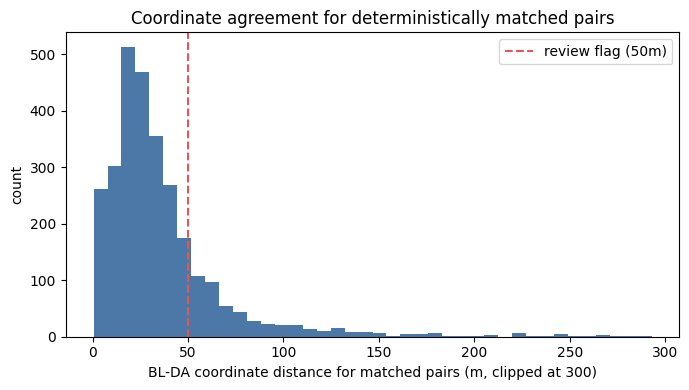

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dist_valid.clip(upper=300), bins=40, color="#4C78A8")
ax.axvline(COORD_REVIEW_FLAG_THRESHOLD_M, color="#E45756", linestyle="--", label=f"review flag ({COORD_REVIEW_FLAG_THRESHOLD_M}m)")
ax.set_xlabel("BL-DA coordinate distance for matched pairs (m, clipped at 300)")
ax.set_ylabel("count")
ax.set_title("Coordinate agreement for deterministically matched pairs")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** the large majority of matched pairs agree spatially to within a few meters, as expected for a genuinely shared address -- this is a sanity check on the address-based matching logic, not a basis for it.

## 9. Industry Compatibility as a Diagnostic, Not a Primary Match Rule

`sector_conflict` was recorded for every Tier 1/2 match above (both sides have a *known*, i.e.
classifiable, sector and those sectors differ). Sector disagreement is reported here for transparency but
**never invalidates an otherwise deterministic match** -- NAICS coding can differ between sources, and
BL's industry field reflects a licensed activity rather than DA's establishment classification, so some
disagreement is expected even for a genuinely correct match. Sector agreement alone is, symmetrically,
never sufficient to create a match on its own.

In [20]:
n_conflict = matched_pairs_df["sector_conflict"].sum()
print(f"Matched pairs with a severe sector conflict (both sectors known and different): {n_conflict:,} of {len(matched_pairs_df):,} ({n_conflict/len(matched_pairs_df)*100:.1f}%)")
print()
print("Example sector-conflict pairs (kept as matches -- shown for transparency only):")
conflict_ids = matched_pairs_df[matched_pairs_df["sector_conflict"]][["bl_id", "da_id"]].head(SAMPLE_N)
for _, r in conflict_ids.iterrows():
    bl_sec, da_sec = bl_by_id.loc[r.bl_id, "sector"], da_by_id.loc[r.da_id, "sector"]
    bl_addr, da_addr = bl_by_id.loc[r.bl_id, "address_original"], da_by_id.loc[r.da_id, "address_original"]
    print(f"  BL sector={bl_sec!r} vs DA sector={da_sec!r} | BL addr={bl_addr!r} DA addr={da_addr!r}")

Matched pairs with a severe sector conflict (both sectors known and different): 1,184 of 2,952 (40.1%)

Example sector-conflict pairs (kept as matches -- shown for transparency only):
  BL sector='Transportation & Warehousing' vs DA sector='Professional, Scientific & Technical Services' | BL addr='7201 EARHART RD' DA addr='7201 Earhart Rd'
  BL sector='Transportation & Warehousing' vs DA sector='Health Care & Social Assistance' | BL addr='1155 3RD ST' DA addr='1155 3rd St'
  BL sector='Transportation & Warehousing' vs DA sector='Retail Trade' | BL addr='4100 REDWOOD RD # 4' DA addr='4100 Redwood Rd # 4'
  BL sector='Transportation & Warehousing' vs DA sector='Manufacturing' | BL addr='941 91ST AVE' DA addr='941 91st Ave'
  BL sector='Accommodation & Food Services' vs DA sector='Retail Trade' | BL addr='4014 MACARTHUR BLVD' DA addr='4014 Macarthur Blvd'


**Takeaway:** sector conflicts are uncommon among deterministic matches and, where they occur, typically reflect genuine coding-scheme differences (e.g. a landlord's NAICS-classified BL license at the same address as a DA-classified tenant business) rather than a wrong match -- consistent with treating this as a diagnostic rather than a filter.

## 10. Create Canonical Entity Records

Every BL and DA working record becomes exactly one canonical row: matched pairs become one `DA_BL`
entity, and every unmatched record becomes its own `DA_only` or `BL_only` entity. Data Axle -- the
richer source, and the only one with a business name -- supplies the descriptive attributes for `DA_BL`
entities (name, home-business flag, employees, sales, year established, etc.), while both sources'
address/coordinate/industry fields are retained separately (`*_da` / `*_bl`) rather than silently
overwritten, so disagreements stay visible.

## 12. Location IDs

Before assembling canonical rows, every BL/DA working record (matched or not) is assigned a
`location_id` for its physical location -- primarily `ZIP + base address`, falling back to rounded
coordinates when the base address is missing, and finally to a record-unique key when neither is
available (such a record cannot be said to share a location with anything). Because Tier 1/2/4 matches
are defined on street-address agreement, a matched pair should almost always share a `location_id` --
checked explicitly below. The rare exception is a pair that agrees on street address but disagrees on
ZIP5 (the other ingredient of the location key); DA's `location_id` is used as authoritative for those
matched entities, consistent with DA being preferred wherever the two sources disagree.

In [21]:
def build_location_keys(df):
    zip5_str = df["zip5"].fillna("NOZIP").astype(str)
    has_addr = df["address_base"].notna()
    addr_key = "ADDR::" + zip5_str + "::" + df["address_base"].fillna("")
    has_geo = df["lat_std"].notna() & df["lon_std"].notna()
    geo_key = "GEO::" + df["lat_std"].round(4).astype(str) + "::" + df["lon_std"].round(4).astype(str)
    unk_key = "UNK::" + df["source"] + "::" + df["source_record_id"]
    return np.select([has_addr, has_geo], [addr_key, geo_key], default=unk_key)

bl_work["location_key"] = build_location_keys(bl_work)
da_work["location_key"] = build_location_keys(da_work)

all_keys = pd.concat([bl_work["location_key"], da_work["location_key"]], ignore_index=True)
codes, uniques = pd.factorize(all_keys)
location_ids_all = ["LOC-%06d" % c for c in codes]
bl_work["location_id"] = location_ids_all[:len(bl_work)]
da_work["location_id"] = location_ids_all[len(bl_work):]

print(f"Unique physical locations across BL ({len(bl_work):,}) + DA ({len(da_work):,}) working records: {len(uniques):,}")

Unique physical locations across BL (45,428) + DA (29,147) working records: 37,905


In [22]:
bl_slim = bl_work.rename(columns=lambda c: f"{c}_bl")
da_slim = da_work.rename(columns=lambda c: f"{c}_da")

matched_full = matched_pairs_df.merge(bl_slim, left_on="bl_id", right_on="source_record_id_bl", how="left")
matched_full = matched_full.merge(da_slim, left_on="da_id", right_on="source_record_id_da", how="left")

loc_mismatch_mask = matched_full["location_id_bl"] != matched_full["location_id_da"]
loc_mismatch = loc_mismatch_mask.sum()
print(f"Matched pairs where BL/DA location_id disagree: {loc_mismatch:,} of {len(matched_full):,}")
if loc_mismatch:
    print("These occur when BL and DA agree on the street address (the basis for the match) but disagree "
          "on ZIP5 (a data-entry/geocoding inconsistency, not a matching error) -- inspect below:")
    print(matched_full.loc[loc_mismatch_mask, ["bl_id", "da_id", "match_method", "address_base_bl", "address_base_da",
                                                "zip5_bl", "zip5_da"]])
# Resolved by taking DA's location_id as authoritative for matched entities (same DA-preference used
# elsewhere in this notebook) -- these few pairs are not blocked on, only reported.

Matched pairs where BL/DA location_id disagree: 2 of 2,952
These occur when BL and DA agree on the street address (the basis for the match) but disagree on ZIP5 (a data-entry/geocoding inconsistency, not a matching error) -- inspect below:
      bl_id  da_id                   match_method    address_base_bl    address_base_da zip5_bl zip5_da
899   14644  10456  exact_full_address_one_to_one        201 13TH ST        201 13TH ST   94604   94612
1772  30848  27907  exact_full_address_one_to_one  9600 SUNNYSIDE ST  9600 SUNNYSIDE ST   94621   94603


In [23]:
canon_matched = pd.DataFrame({
    "business_name": matched_full["business_name_da"],
    "address": matched_full["address_original_da"],
    "address_base": matched_full["address_base_da"],
    "unit": matched_full["address_unit_da"].fillna(matched_full["address_unit_bl"]),
    "zip5": matched_full["zip5_da"].fillna(matched_full["zip5_bl"]),
    "latitude": matched_full["lat_std_da"].fillna(matched_full["lat_std_bl"]),
    "longitude": matched_full["lon_std_da"].fillna(matched_full["lon_std_bl"]),
    "broad_sector": matched_full["sector_da"],
    "location_id": matched_full["location_id_da"],
    "in_data_axle": True, "in_business_license": True,
    "da_source_record_id": matched_full["da_id"], "bl_source_record_id": matched_full["bl_id"],
    "match_method": matched_full["match_method"], "match_confidence": matched_full["match_confidence"],
    "coord_distance_m": matched_full["dist_m"], "coord_flag": matched_full["coord_flag"],
    "sector_conflict": matched_full["sector_conflict"], "ambiguous_shared_location": False,
    "naics_da": matched_full["industry_code_original_da"], "naics_desc_da": matched_full["Primary NAICS Description_da"],
    "sic_da": matched_full["Primary SIC Code_da"], "sic_desc_da": matched_full["Primary SIC Description_da"],
    "naics_bl": matched_full["industry_code_original_bl"], "naics_desc_bl": matched_full["industry_description_original_bl"],
    "sector_da": matched_full["sector_da"], "sector_bl": matched_full["sector_bl"],
    "latitude_da": matched_full["lat_std_da"], "longitude_da": matched_full["lon_std_da"],
    "latitude_bl": matched_full["lat_std_bl"], "longitude_bl": matched_full["lon_std_bl"],
    "address_da_original": matched_full["address_original_da"], "address_bl_original": matched_full["address_original_bl"],
    "location_type_da": matched_full["Location Type_da"], "type_of_business_da": matched_full["Type of Business_da"],
    "home_business": matched_full["Home Business_da"].eq("Yes"),
    "employee_range": matched_full["Location Employee Size Range_da"], "employees": matched_full["Location Employee Size Actual_da"],
    "sales_range": matched_full["Location Sales Volume Range_da"], "sales": matched_full["Location Sales Volume Actual_da"],
    "year_established": matched_full["Year Established_da"], "years_in_database": matched_full["Years In Database_da"],
    "franchise_da": matched_full["Franchise Description 1_da"], "affiliated_records_da": matched_full["Affiliated Records_da"],
    "affiliated_locations_da": matched_full["Affiliated Locations_da"], "square_footage_da": matched_full["Square Footage_da"],
    "credit_score_da": matched_full["Credit Score Alpha_da"], "phone_da": matched_full["Phone Number Combined_da"],
    "own_or_lease_da": matched_full["Own or Lease_da"], "firm_or_individual_da": matched_full["Firm or Individual_da"],
    "government_office_da": matched_full["Government Office_da"],
})
canon_matched["source_type"] = "DA_BL"
print("canon_matched:", canon_matched.shape)

canon_matched: (2952, 52)


In [24]:
bl_already_matched = set(matched_pairs_df["bl_id"])
da_already_matched = set(matched_pairs_df["da_id"])
bl_only_df = bl_work[~bl_work["source_record_id"].isin(bl_already_matched)].copy()
da_only_df = da_work[~da_work["source_record_id"].isin(da_already_matched)].copy()

canon_da_only = pd.DataFrame({
    "business_name": da_only_df["business_name"], "address": da_only_df["address_original"],
    "address_base": da_only_df["address_base"], "unit": da_only_df["address_unit"], "zip5": da_only_df["zip5"],
    "latitude": da_only_df["lat_std"], "longitude": da_only_df["lon_std"], "broad_sector": da_only_df["sector"],
    "location_id": da_only_df["location_id"], "in_data_axle": True, "in_business_license": False,
    "da_source_record_id": da_only_df["source_record_id"], "bl_source_record_id": np.nan,
    "match_method": "DA_only", "match_confidence": "source_only",
    "coord_distance_m": np.nan, "coord_flag": False, "sector_conflict": False,
    "ambiguous_shared_location": da_only_df["address_base"].notna() & da_only_df["address_base"].isin(bl_work["address_base"].dropna().unique()),
    "naics_da": da_only_df["industry_code_original"], "naics_desc_da": da_only_df["Primary NAICS Description"],
    "sic_da": da_only_df["Primary SIC Code"], "sic_desc_da": da_only_df["Primary SIC Description"],
    "naics_bl": np.nan, "naics_desc_bl": np.nan, "sector_da": da_only_df["sector"], "sector_bl": np.nan,
    "latitude_da": da_only_df["lat_std"], "longitude_da": da_only_df["lon_std"], "latitude_bl": np.nan, "longitude_bl": np.nan,
    "address_da_original": da_only_df["address_original"], "address_bl_original": np.nan,
    "location_type_da": da_only_df["Location Type"], "type_of_business_da": da_only_df["Type of Business"],
    "home_business": da_only_df["Home Business"].eq("Yes"),
    "employee_range": da_only_df["Location Employee Size Range"], "employees": da_only_df["Location Employee Size Actual"],
    "sales_range": da_only_df["Location Sales Volume Range"], "sales": da_only_df["Location Sales Volume Actual"],
    "year_established": da_only_df["Year Established"], "years_in_database": da_only_df["Years In Database"],
    "franchise_da": da_only_df["Franchise Description 1"], "affiliated_records_da": da_only_df["Affiliated Records"],
    "affiliated_locations_da": da_only_df["Affiliated Locations"], "square_footage_da": da_only_df["Square Footage"],
    "credit_score_da": da_only_df["Credit Score Alpha"], "phone_da": da_only_df["Phone Number Combined"],
    "own_or_lease_da": da_only_df["Own or Lease"], "firm_or_individual_da": da_only_df["Firm or Individual"],
    "government_office_da": da_only_df["Government Office"],
})
canon_da_only["source_type"] = "DA_only"

canon_bl_only = pd.DataFrame({
    "business_name": np.nan, "address": bl_only_df["address_original"], "address_base": bl_only_df["address_base"],
    "unit": bl_only_df["address_unit"], "zip5": bl_only_df["zip5"], "latitude": bl_only_df["lat_std"],
    "longitude": bl_only_df["lon_std"], "broad_sector": bl_only_df["sector"], "location_id": bl_only_df["location_id"],
    "in_data_axle": False, "in_business_license": True,
    "da_source_record_id": np.nan, "bl_source_record_id": bl_only_df["source_record_id"],
    "match_method": "BL_only", "match_confidence": "source_only",
    "coord_distance_m": np.nan, "coord_flag": False, "sector_conflict": False,
    "ambiguous_shared_location": bl_only_df["address_base"].notna() & bl_only_df["address_base"].isin(da_work["address_base"].dropna().unique()),
    "naics_da": np.nan, "naics_desc_da": np.nan, "sic_da": np.nan, "sic_desc_da": np.nan,
    "naics_bl": bl_only_df["industry_code_original"], "naics_desc_bl": bl_only_df["industry_description_original"],
    "sector_da": np.nan, "sector_bl": bl_only_df["sector"],
    "latitude_da": np.nan, "longitude_da": np.nan, "latitude_bl": bl_only_df["lat_std"], "longitude_bl": bl_only_df["lon_std"],
    "address_da_original": np.nan, "address_bl_original": bl_only_df["address_original"],
    "location_type_da": np.nan, "type_of_business_da": np.nan, "home_business": np.nan,
    "employee_range": np.nan, "employees": np.nan, "sales_range": np.nan, "sales": np.nan,
    "year_established": np.nan, "years_in_database": np.nan, "franchise_da": np.nan,
    "affiliated_records_da": np.nan, "affiliated_locations_da": np.nan, "square_footage_da": np.nan,
    "credit_score_da": np.nan, "phone_da": np.nan, "own_or_lease_da": np.nan, "firm_or_individual_da": np.nan,
    "government_office_da": np.nan,
})
canon_bl_only["source_type"] = "BL_only"

canonical_df = pd.concat([canon_matched, canon_da_only, canon_bl_only], ignore_index=True)
canonical_df["canonical_business_id"] = ["BIZ-%06d" % i for i in range(1, len(canonical_df) + 1)]
canonical_df["source_count"] = canonical_df[["in_data_axle", "in_business_license"]].sum(axis=1)
print("canonical_df assembled:", canonical_df.shape)
canonical_df["source_type"].value_counts()

canonical_df assembled: (71623, 54)


source_type
BL_only    42476
DA_only    26195
DA_BL       2952
Name: count, dtype: int64

**Takeaway:** every canonical entity carries source-specific fields (`*_da`, `*_bl`) alongside the blended canonical fields, so a disagreement between sources is never silently erased -- it is visible in the underlying columns even where a single canonical value had to be chosen.

## 11. Source Provenance

Every canonical record's source support is summarized by `in_data_axle`, `in_business_license`,
`source_count`, and `source_type` (`DA_only` / `BL_only` / `DA_BL`), plus the original
`da_source_record_id` / `bl_source_record_id` where applicable, and `match_method` /
`match_confidence`. `match_confidence` uses three explicit values only: `source_only` (no cross-source
evidence exists or is needed), `high` (Tiers 1/2 -- pure address uniqueness), and `medium` (Tier 4 -- a
coordinate-isolation rule that is deterministic but relies on more circumstantial evidence than pure
address matching). No `match_confidence` value is assigned without a clearly defined rule behind it.

In [25]:
print(canonical_df["match_method"].value_counts())
print()
print(canonical_df["match_confidence"].value_counts())

match_method
BL_only                             42476
DA_only                             26195
exact_full_address_one_to_one        2666
exact_base_address_one_to_one         285
exact_unit_unique_correspondence        1
Name: count, dtype: int64

match_confidence
source_only    68671
high            2951
medium             1
Name: count, dtype: int64


## 13. Retain All Unmatched Records

The canonical dataset is the **union** of BL and DA after only clear source-processing duplicates were
removed (Section 5) -- not the intersection, and not limited to matched pairs. BL and DA capture
different, only partially-overlapping business universes, so a record is never dropped merely for
lacking support from the other source.

In [26]:
assert len(canonical_df) == len(canon_matched) + len(canon_da_only) + len(canon_bl_only)
print(f"DA_BL (confidently matched):  {len(canon_matched):,}")
print(f"DA_only (unmatched):          {len(canon_da_only):,}")
print(f"BL_only (unmatched):          {len(canon_bl_only):,}")
print(f"Total canonical entities:     {len(canonical_df):,}")
print(f"\nUnion check -- every BL working record accounted for: {canonical_df['in_business_license'].sum() == len(bl_work)}")
print(f"Union check -- every DA working record accounted for: {canonical_df['in_data_axle'].sum() == len(da_work)}")

DA_BL (confidently matched):  2,952
DA_only (unmatched):          26,195
BL_only (unmatched):          42,476
Total canonical entities:     71,623

Union check -- every BL working record accounted for: True
Union check -- every DA working record accounted for: True


## 14. Preserve Useful Source-Specific Flags

No records are removed at this stage based on assumed corridor relevance. A few derived flags are added
for later analytical use -- all clearly documented, and `commercial_relevance_class` is explicitly
tentative and must never be used to drop records:

- `home_business`: DA's own `Home Business == "Yes"` flag (BL has no equivalent; left null for BL-only).
- `likely_property_license`: **tentative**, BL-only heuristic -- BL has no license-type field, so this is
  inferred only from the NAICS description text containing a lessor/property-management phrase (e.g.
  "Lessors of Residential Buildings and Dwellings"). It flags likely rental/property licenses rather than
  operating businesses, not a confirmed classification.
- `broad_sector`: canonical sector (DA-preferred, falling back to BL where DA is absent).
- `commercial_relevance_class`: **tentative**, sector-based grouping into
  `consumer_facing` / `office_or_professional` / `industrial_or_logistics` / `other`, from
  `SECTOR_TO_RELEVANCE`. This is a coarse, documented convenience grouping, not a validated measure of
  actual corridor relevance.

In [27]:
canonical_df["likely_property_license"] = (
    canonical_df["naics_desc_bl"].fillna("").str.upper()
    .apply(lambda s: any(k in s for k in PROPERTY_LICENSE_NAICS_KEYWORDS))
)
canonical_df["commercial_relevance_class"] = canonical_df["broad_sector"].map(SECTOR_TO_RELEVANCE).fillna("other")

print("home_business (DA-supported entities only):")
print(canonical_df.loc[canonical_df["in_data_axle"], "home_business"].value_counts(dropna=False))
n_bl_supported = canonical_df["in_business_license"].sum()
n_property_flagged = canonical_df.loc[canonical_df["in_business_license"], "likely_property_license"].sum()
print(f"\nlikely_property_license flagged (BL-supported entities): {n_property_flagged:,} of {n_bl_supported:,}")
print("\ncommercial_relevance_class distribution:")
print(canonical_df["commercial_relevance_class"].value_counts(normalize=True).mul(100).round(1))

home_business (DA-supported entities only):
home_business
0.0    26322
1.0     2825
Name: count, dtype: int64

likely_property_license flagged (BL-supported entities): 21,454 of 45,428

commercial_relevance_class distribution:
commercial_relevance_class
office_or_professional     51.0
consumer_facing            33.9
other                       8.8
industrial_or_logistics     6.3
Name: proportion, dtype: float64


## 15. Residual Duplication Diagnostics

After the deterministic merge, remaining possible duplicates are inspected -- but not automatically
collapsed. Section 5 already removed clear processing duplicates within each source; what's checked here
is whether any *canonical* entities still look suspiciously alike (same DA business name at the same
full address, but not merged in Section 5 because some other identifying field, such as phone number,
differed). These are reported as candidates for manual follow-up, not resolved automatically -- doing so
would reintroduce exactly the aggressive-collapsing risk this notebook is designed to avoid.

In [28]:
da_linked = canonical_df[canonical_df["in_data_axle"] & canonical_df["business_name"].notna()]
resid_dup_mask = da_linked.duplicated(subset=["business_name", "address"], keep=False)
print(f"Residual same-name/same-full-address DA-linked canonical entities not collapsed in Section 5: "
      f"{resid_dup_mask.sum():,} rows ({da_linked.loc[resid_dup_mask, 'canonical_business_id'].nunique() if resid_dup_mask.any() else 0:,} distinct entities)")
if resid_dup_mask.any():
    da_linked.loc[resid_dup_mask, ["canonical_business_id", "business_name", "address", "source_type", "naics_desc_da"]].sort_values("business_name").head(10)

Residual same-name/same-full-address DA-linked canonical entities not collapsed in Section 5: 317 rows (317 distinct entities)


**Takeaway:** any residual cases are reported for awareness, not auto-merged -- consistent with this notebook's stated tolerance for some unresolved true duplicates in exchange for avoiding false-positive merges.

## 16. Validate the Final Dataset

### Source composition

In [29]:
comp = canonical_df["source_type"].value_counts()
comp_pct = (comp / comp.sum() * 100).round(1)
pd.DataFrame({"n": comp, "pct": comp_pct})

,n,pct
source_type,,
BL_only,42476,59.3
DA_only,26195,36.6
DA_BL,2952,4.1


### Match methods

In [30]:
canonical_df["match_method"].value_counts()

match_method
BL_only                             42476
DA_only                             26195
exact_full_address_one_to_one        2666
exact_base_address_one_to_one         285
exact_unit_unique_correspondence        1
Name: count, dtype: int64

### Match cardinality

Cardinality of base addresses shared by BL and DA, recomputed on the post-deduplication working frames
(`bl_work`/`da_work`), plus how much of the one-to-one class actually produced a match, and how many
one-to-many/many-to-many sites remain unresolved (i.e. still contain at least one BL-only or DA-only
entity flagged `ambiguous_shared_location`).

In [31]:
def cardinality_label(b, d):
    if b == 1 and d == 1: return "one-to-one"
    if b == 1 or d == 1: return "one-to-many"
    return "many-to-many"

common_base_work = sorted(set(bl_base_counts.index) & set(da_base_counts.index))
card_work = pd.Series([cardinality_label(bl_base_counts[k], da_base_counts[k]) for k in common_base_work], index=common_base_work)
print(f"{len(common_base_work):,} base addresses shared by BL and DA (post-dedup). Cardinality:")
print(card_work.value_counts())
print(card_work.value_counts(normalize=True).mul(100).round(1))

n_ambiguous_entities = canonical_df["ambiguous_shared_location"].sum()
print(f"\nCanonical entities left separate at a shared, unresolved location (ambiguous_shared_location): {n_ambiguous_entities:,}")
print(f"Canonical entities resolved via Tier 1/2/4 matching:                                             {len(canon_matched):,}")

6,244 base addresses shared by BL and DA (post-dedup). Cardinality:
one-to-one      2650
one-to-many     2198
many-to-many    1396
Name: count, dtype: int64
one-to-one      42.4
one-to-many     35.2
many-to-many    22.4
Name: proportion, dtype: float64

Canonical entities left separate at a shared, unresolved location (ambiguous_shared_location): 31,297
Canonical entities resolved via Tier 1/2/4 matching:                                             2,952


### Entity / location counts

In [32]:
n_entities = canonical_df["canonical_business_id"].nunique()
n_locations = canonical_df["location_id"].nunique()
per_location = canonical_df.groupby("location_id").size()
high_count_locations = per_location[per_location >= HIGH_COUNT_ADDR_THRESHOLD]

print(f"Canonical business entities: {n_entities:,}")
print(f"Unique physical locations:   {n_locations:,}")
print(f"Businesses per location -- mean {per_location.mean():.2f}, median {per_location.median():.0f}, max {per_location.max()}")
print(f"Locations with >= {HIGH_COUNT_ADDR_THRESHOLD} businesses: {len(high_count_locations):,}, covering {high_count_locations.sum():,} entities "
      f"({high_count_locations.sum()/n_entities*100:.1f}% of all entities)")

Canonical business entities: 71,623
Unique physical locations:   37,904
Businesses per location -- mean 1.89, median 1, max 704
Locations with >= 5 businesses: 1,466, covering 26,288 entities (36.7% of all entities)


### Sector composition -- original BL vs. original DA vs. final canonical

In [33]:
sector_compare = pd.DataFrame({
    "BL_original_pct": (bl_std["sector"].value_counts(normalize=True) * 100),
    "DA_original_pct": (da_std["sector"].value_counts(normalize=True) * 100),
    "Canonical_pct": (canonical_df["broad_sector"].value_counts(normalize=True) * 100),
}).reindex(SECTOR_ORDER).round(1)
sector_compare

,BL_original_pct,DA_original_pct,Canonical_pct
Retail Trade,6.1,6.3,5.9
Accommodation & Food Services,3.3,4.9,3.7
Health Care & Social Assistance,2.5,36.8,16.1
"Professional, Scientific & Technical Services",7.9,10.7,9.0
"Finance, Insurance & Real Estate",55.9,6.9,37.6
Construction,1.7,3.4,2.4
Manufacturing,1.7,1.8,1.7
Transportation & Warehousing,0.8,1.4,1.0
Wholesale Trade,0.9,1.6,1.2
Administrative & Support Services,3.2,2.1,2.8


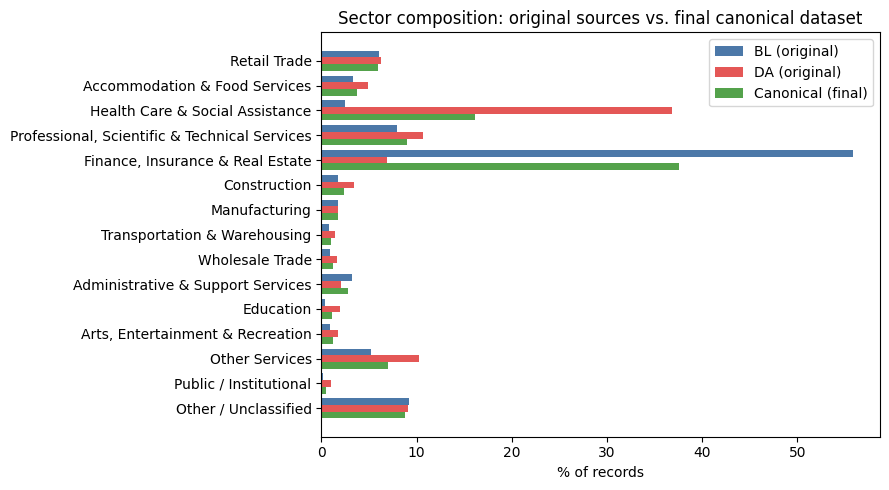

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SECTOR_ORDER))
w = 0.27
ax.barh(x - w, sector_compare["BL_original_pct"].fillna(0), height=w, label="BL (original)", color="#4C78A8")
ax.barh(x, sector_compare["DA_original_pct"].fillna(0), height=w, label="DA (original)", color="#E45756")
ax.barh(x + w, sector_compare["Canonical_pct"].fillna(0), height=w, label="Canonical (final)", color="#54A24B")
ax.set_yticks(x); ax.set_yticklabels(SECTOR_ORDER); ax.invert_yaxis()
ax.set_xlabel("% of records"); ax.set_title("Sector composition: original sources vs. final canonical dataset")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** the canonical sector mix sits close to a blend of the two originals (as expected, since matched entities keep DA's sector and unmatched entities keep their own source's sector) -- no sector is inadvertently eliminated or disproportionately collapsed by the merge procedure.

### Spatial validation (DA_BL entities)

In [35]:
da_bl_rows = canonical_df[canonical_df["source_type"] == "DA_BL"]
print("Coordinate distance distribution for matched (DA_BL) entities -- see also Section 8:")
print(da_bl_rows["coord_distance_m"].describe().round(1))
print()
print("Examples with the largest coordinate disagreement among matched entities:")
da_bl_rows.dropna(subset=["coord_distance_m"]).sort_values("coord_distance_m", ascending=False)[
    ["canonical_business_id", "business_name", "address", "match_method", "coord_distance_m", "coord_flag"]
].head(SAMPLE_N)

Coordinate distance distribution for matched (DA_BL) entities -- see also Section 8:
count    2843.0
mean       36.2
std        34.0
min         0.5
25%        17.3
50%        27.6
75%        43.6
max       292.8
Name: coord_distance_m, dtype: float64

Examples with the largest coordinate disagreement among matched entities:


,canonical_business_id,business_name,address,match_method,coord_distance_m,coord_flag
2258,BIZ-002259,Satellite St Andrew's Manor,3250 San Pablo Ave,exact_full_address_one_to_one,292.827619,True
2841,BIZ-002842,San Francisco Public Defender,8681 Mountain Blvd,exact_base_address_one_to_one,290.411136,True
1798,BIZ-001799,Old Dominion,8300 Pardee Dr,exact_full_address_one_to_one,285.477952,True
1808,BIZ-001809,One Workplace L Ferrari,7220 Edgewater Dr,exact_full_address_one_to_one,272.279097,True
1581,BIZ-001582,"Bower, Danielle",746 Grand Ave,exact_full_address_one_to_one,270.729212,True


### Address validation -- representative examples

In [36]:
print("Tier 1 examples (exact full address, clean one-to-one):")
da_bl_rows[da_bl_rows["match_method"] == "exact_full_address_one_to_one"][
    ["canonical_business_id", "business_name", "address", "coord_distance_m"]
].head(SAMPLE_N)

Tier 1 examples (exact full address, clean one-to-one):


,canonical_business_id,business_name,address,coord_distance_m
0,BIZ-000001,DHL Express Servicepoint,7201 Earhart Rd,247.403160
1,BIZ-000002,C Trans Inc,9201 San Leandro St,70.983399
2,BIZ-000003,Mutual Express,1700 W Grand Ave,6.558256
3,BIZ-000004,Big Family Movers,3955 Whittle Ave,21.891501
4,BIZ-000005,Quintero Trucking,2270 Poplar St,96.601971


In [37]:
print("Tier 2 examples (exact base address, clean one-to-one):")
da_bl_rows[da_bl_rows["match_method"] == "exact_base_address_one_to_one"][
    ["canonical_business_id", "business_name", "address", "coord_distance_m"]
].head(SAMPLE_N)

Tier 2 examples (exact base address, clean one-to-one):


,canonical_business_id,business_name,address,coord_distance_m
2666,BIZ-002667,City Of Walnut Creek,394 Orange St # 4,22.236168
2667,BIZ-002668,Myco Custom Painting,1921 26th Ave # 23,19.180171
2668,BIZ-002669,Reunion Covenant Church,274 40th Street Way # 16,31.413246
2669,BIZ-002670,Afghan Foods LLC,200 E 15th St # 12,31.008060
2670,BIZ-002671,Relaxation Labs LLC,301 Lenox Ave # 202,33.107034


In [38]:
print("DA-only examples:")
canon_da_only[["business_name", "address", "broad_sector"]].head(SAMPLE_N)

DA-only examples:


,business_name,address,broad_sector
0,0-90 Health & Human Servicing,7957- Greenly Drive Oakland CA,Other / Unclassified
2,10-4 Tow Of Oakland,1409 35th Ave # 94601,Transportation & Warehousing
4,100 Mac 76,100 Macarthur Blvd,Retail Trade
5,100 Oak Street Corp,447 29th St,Other Services
6,1000 NW 19th Property Owner,4169 Rettig Ave,Other Services


In [39]:
print("BL-only examples:")
canon_bl_only[["address", "broad_sector", "naics_desc_bl"]].head(SAMPLE_N)

BL-only examples:


,address,broad_sector,naics_desc_bl
0,3775 ALAMEDA AVE STE B,Transportation & Warehousing,"General Freight Trucking, Local"
2,1707 WOOD ST,Transportation & Warehousing,All Other Transit and Ground Passenger Transportation
3,530 WATER ST,Transportation & Warehousing,"General Freight Trucking, Local"
4,737 BAY ST,Transportation & Warehousing,"General Freight Trucking, Local"
5,1425 MARITIME ST,Transportation & Warehousing,"General Freight Trucking, Local"


In [40]:
print("Ambiguous shared-location examples (deliberately NOT merged):")
canonical_df[canonical_df["ambiguous_shared_location"]][
    ["canonical_business_id", "source_type", "business_name", "address", "broad_sector"]
].head(SAMPLE_N)

Ambiguous shared-location examples (deliberately NOT merged):


,canonical_business_id,source_type,business_name,address,broad_sector
2953,BIZ-002954,DA_only,10-4 Tow Of Oakland,1409 35th Ave # 94601,Transportation & Warehousing
2954,BIZ-002955,DA_only,100 Mac 76,100 Macarthur Blvd,Retail Trade
2956,BIZ-002957,DA_only,1000 NW 19th Property Owner,4169 Rettig Ave,Other Services
2957,BIZ-002958,DA_only,101 Broadway Ventures LLC,317 Washington St,Other / Unclassified
2959,BIZ-002960,DA_only,1010 38th Ave LLC,1940 Union St # 9,Other / Unclassified


## 17. Account for Every Source Record

Before anything is exported, every input record must be accounted for. The **source crosswalk** (one row
per original source record represented in the canonical dataset -- 1 row for a `DA_only`/`BL_only`
entity, 2 rows for a `DA_BL` entity) is built here, and a reconciliation table plus a set of hard
`assert` checks confirm the merge did not lose, duplicate, or misassign any record. **If any check fails,
the notebook stops here and nothing is exported.**

In [41]:
cw_da_side = canonical_df[canonical_df["in_data_axle"]].copy()
cw_da_side["source"] = "DA"
cw_da_side["source_record_id"] = cw_da_side["da_source_record_id"]
cw_da_side["original_name"] = cw_da_side["business_name"]
cw_da_side["original_address"] = cw_da_side["address_da_original"]
cw_da_side["original_sector"] = cw_da_side["sector_da"]

cw_bl_side = canonical_df[canonical_df["in_business_license"]].copy()
cw_bl_side["source"] = "BL"
cw_bl_side["source_record_id"] = cw_bl_side["bl_source_record_id"]
cw_bl_side["original_name"] = np.nan
cw_bl_side["original_address"] = cw_bl_side["address_bl_original"]
cw_bl_side["original_sector"] = cw_bl_side["sector_bl"]

CROSSWALK_COLS = ["canonical_business_id", "location_id", "source", "source_record_id",
                  "match_method", "match_confidence", "original_name", "original_address", "original_sector"]
crosswalk_df = pd.concat([cw_da_side[CROSSWALK_COLS], cw_bl_side[CROSSWALK_COLS]], ignore_index=True)
print("crosswalk_df:", crosswalk_df.shape)
crosswalk_df.head(6)

crosswalk_df: (74575, 9)


,canonical_business_id,location_id,source,source_record_id,match_method,match_confidence,original_name,original_address,original_sector
0,BIZ-000001,LOC-000001,DA,7737,exact_full_address_one_to_one,high,DHL Express Servicepoint,7201 Earhart Rd,"Professional, Scientific & Technical Services"
1,BIZ-000002,LOC-000011,DA,4744,exact_full_address_one_to_one,high,C Trans Inc,9201 San Leandro St,Transportation & Warehousing
2,BIZ-000003,LOC-000020,DA,18511,exact_full_address_one_to_one,high,Mutual Express,1700 W Grand Ave,Transportation & Warehousing
3,BIZ-000004,LOC-000036,DA,3762,exact_full_address_one_to_one,high,Big Family Movers,3955 Whittle Ave,Transportation & Warehousing
4,BIZ-000005,LOC-000043,DA,21971,exact_full_address_one_to_one,high,Quintero Trucking,2270 Poplar St,Transportation & Warehousing
5,BIZ-000006,LOC-000045,DA,21915,exact_full_address_one_to_one,high,Quality Transit LLC,828 27th Ave,Transportation & Warehousing


In [42]:
reconciliation = pd.DataFrame({
    "Source": ["DA", "BL"],
    "Raw records": [len(da_std), len(bl_std)],
    "Exact duplicates removed": [len(da_removed_dup_ids), len(bl_removed_dup_ids)],
    "Records represented in canonical dataset": [int(canonical_df["in_data_axle"].sum()), int(canonical_df["in_business_license"].sum())],
})
reconciliation["Raw = duplicates removed + represented"] = (
    reconciliation["Raw records"]
    == reconciliation["Exact duplicates removed"] + reconciliation["Records represented in canonical dataset"]
)
reconciliation

,Source,Raw records,Exact duplicates removed,Records represented in canonical dataset,Raw = duplicates removed + represented
0,DA,29545,398,29147,True
1,BL,46514,1086,45428,True


In [43]:
# ---- hard reconciliation checks -- export is blocked below if any of these fail ----
checks = {}

checks["every retained DA record maps to exactly one canonical_business_id"] = (
    canonical_df["da_source_record_id"].dropna().duplicated().sum() == 0
)
checks["every retained BL record maps to exactly one canonical_business_id"] = (
    canonical_df["bl_source_record_id"].dropna().duplicated().sum() == 0
)
checks["every DA working record is represented exactly once"] = (
    set(canonical_df["da_source_record_id"].dropna()) == set(da_work["source_record_id"])
)
checks["every BL working record is represented exactly once"] = (
    set(canonical_df["bl_source_record_id"].dropna()) == set(bl_work["source_record_id"])
)
checks["canonical_business_id is unique"] = canonical_df["canonical_business_id"].is_unique
checks["DA_BL entities have exactly the expected two-row provenance"] = (
    crosswalk_df.groupby("canonical_business_id").size()
    .loc[canonical_df.loc[canonical_df["source_type"] == "DA_BL", "canonical_business_id"]].eq(2).all()
)
checks["source-only entities have exactly one row of provenance"] = (
    crosswalk_df.groupby("canonical_business_id").size()
    .loc[canonical_df.loc[canonical_df["source_type"] != "DA_BL", "canonical_business_id"]].eq(1).all()
)
checks["output row count equals canonical entity count"] = len(canonical_df) == n_entities

for name, ok in checks.items():
    print(("PASS" if ok else "FAIL") + " -- " + name)

assert all(checks.values()), "One or more reconciliation checks failed -- fix before exporting."
print("\nAll reconciliation checks passed. Safe to export.")

PASS -- every retained DA record maps to exactly one canonical_business_id
PASS -- every retained BL record maps to exactly one canonical_business_id
PASS -- every DA working record is represented exactly once
PASS -- every BL working record is represented exactly once
PASS -- canonical_business_id is unique
PASS -- DA_BL entities have exactly the expected two-row provenance
PASS -- source-only entities have exactly one row of provenance
PASS -- output row count equals canonical entity count

All reconciliation checks passed. Safe to export.


## 18. Output Data

The main output is **one row per canonical business entity**, written to
`data/business/combined/oakland_businesses_combined.csv`. Column names are snake_case throughout.

In [44]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_COLUMNS = [
    "canonical_business_id", "location_id", "business_name",
    "address", "address_base", "unit", "zip5", "latitude", "longitude",
    "broad_sector", "home_business", "likely_property_license", "commercial_relevance_class",
    "employee_range", "employees", "sales_range", "sales", "year_established", "years_in_database",
    "in_data_axle", "in_business_license", "source_count", "source_type",
    "da_source_record_id", "bl_source_record_id", "match_method", "match_confidence",
    "coord_distance_m", "coord_flag", "sector_conflict", "ambiguous_shared_location",
    "naics_da", "naics_desc_da", "sic_da", "sic_desc_da", "naics_bl", "naics_desc_bl",
    "sector_da", "sector_bl", "latitude_da", "longitude_da", "latitude_bl", "longitude_bl",
    "address_da_original", "address_bl_original",
    "location_type_da", "type_of_business_da", "franchise_da",
    "affiliated_records_da", "affiliated_locations_da", "square_footage_da", "credit_score_da",
    "phone_da", "own_or_lease_da", "firm_or_individual_da", "government_office_da",
]
assert set(OUTPUT_COLUMNS) == set(canonical_df.columns), "Output column list must match canonical_df exactly."

canonical_df[OUTPUT_COLUMNS].to_csv(OUTPUT_MAIN_PATH, index=False)
print(f"Wrote {len(canonical_df):,} rows x {len(OUTPUT_COLUMNS)} columns to {OUTPUT_MAIN_PATH}")

Wrote 71,623 rows x 56 columns to ../../data/business/combined/oakland_businesses_combined.csv


## 19. Create a Source Crosswalk / Provenance File

`crosswalk_df` (built in Section 17) is written to
`data/business/combined/oakland_business_source_crosswalk.csv` -- one row per original source record
represented in the canonical dataset, so every canonical business is traceable back to the original BL
and/or DA record(s) it came from.

In [45]:
crosswalk_df.to_csv(OUTPUT_CROSSWALK_PATH, index=False)
print(f"Wrote {len(crosswalk_df):,} rows x {len(crosswalk_df.columns)} columns to {OUTPUT_CROSSWALK_PATH}")

Wrote 74,575 rows x 9 columns to ../../data/business/combined/oakland_business_source_crosswalk.csv


## Key Findings and Final Dataset

In [46]:
pct_both = canon_matched.shape[0] / n_entities * 100
print("SOURCE RECORDS")
print(f"  Raw DA records:                  {len(da_std):,}")
print(f"  Raw BL records:                  {len(bl_std):,}")
print(f"  DA exact duplicates removed:     {len(da_removed_dup_ids):,}")
print(f"  BL exact duplicates removed:     {len(bl_removed_dup_ids):,}")
print()
print("MATCHING")
print(f"  Confident DA-BL matches (all tiers):        {len(canon_matched):,}")
for m, n in canonical_df["match_method"].value_counts().items():
    print(f"    {m:<40s} {n:,}")
print(f"  Ambiguous shared-location entities left unmerged: {int(canonical_df['ambiguous_shared_location'].sum()):,}")
print()
print("CANONICAL DATASET")
print(f"  DA-only entities:                {len(canon_da_only):,}")
print(f"  BL-only entities:                {len(canon_bl_only):,}")
print(f"  Total canonical entities:        {n_entities:,}")
print(f"  Total physical locations:        {n_locations:,}")
print(f"  % of entities supported by both BL and DA: {pct_both:.1f}%")
print()
print("OUTPUT FILES")
print(f"  {OUTPUT_MAIN_PATH}")
print(f"  {OUTPUT_CROSSWALK_PATH}")

SOURCE RECORDS
  Raw DA records:                  29,545
  Raw BL records:                  46,514
  DA exact duplicates removed:     398
  BL exact duplicates removed:     1,086

MATCHING
  Confident DA-BL matches (all tiers):        2,952
    BL_only                                  42,476
    DA_only                                  26,195
    exact_full_address_one_to_one            2,666
    exact_base_address_one_to_one            285
    exact_unit_unique_correspondence         1
  Ambiguous shared-location entities left unmerged: 31,297

CANONICAL DATASET
  DA-only entities:                26,195
  BL-only entities:                42,476
  Total canonical entities:        71,623
  Total physical locations:        37,904
  % of entities supported by both BL and DA: 4.1%

OUTPUT FILES
  ../../data/business/combined/oakland_businesses_combined.csv
  ../../data/business/combined/oakland_business_source_crosswalk.csv


**Major remaining limitations:**

- Genuine duplicate businesses almost certainly remain unresolved in the `DA_only`/`BL_only` pools --
  this is an intended cost of the conservative approach, not an oversight.
- BL has no business name, so a BL record can only ever be matched or left alone on address evidence;
  it can never be positively *confirmed* as the same entity the way two named records could be.
- `ambiguous_shared_location` entities are exactly the multi-tenant / shared-building cases this notebook
  is unwilling to resolve automatically -- they remain a known, flagged source of latent duplication.
- Tier 4's coordinate-isolation rule is deterministic but more circumstantial than Tiers 1/2, and is
  marked `match_confidence = "medium"` rather than `"high"` for that reason.
- D&B is excluded entirely from this merge (see the notebook introduction) and is not reflected anywhere
  in the output files.

**Guiding philosophy of this merge:**

> The combined dataset prioritizes precision of entity resolution over maximizing match rate. BL and DA
> records are merged only when strong deterministic evidence supports treating them as the same entity.
> Ambiguous cases are retained separately, even when this means some true duplicates remain unresolved,
> because avoiding false-positive business matches is the higher priority.